# G. GPU 병렬 연산 (CuPy)

GPU를 사용하여 기존 `NumPy` 배열 연산을 더욱 빠르게 수행할 수 있습니다. 그러기 위해서는 `NumPy`와 호환되는 GPU 배열 연산 라이브러리인 `CuPy`를 사용합니다.

`CuPy`:
* NumPy와 호환되는 GPU 배열 라이브러리
* NumPy와 유사한 문법으로 GPU 배열 연산
* NVIDIA CUDA를 활용하여 대규모 연산을 GPU에서 가속


현재 개발 환경인 JetPack 6.2, CUDA 12.6, NumPy 1.21.5에 맞춰 CuPy를 설치해야 합니다.

```bash
python -m pip download --no-deps --only-binary=:all: "cupy-cuda12x==12.3.0" -d ~/Downloads
python -m pip install --no-deps "fastrlock==0.8.3"
python -m pip install --no-deps --only-binary=:all: ~/Downloads/cupy_cuda12x-12.3.0-*.whl
```

설치가 제대로 되었는지 확인해봅시다.

In [1]:
import numpy as np
import cupy as cp

print("NumPy :", np.__version__)
print("CuPy  :", cp.__version__)

c:\Users\actua\t1_vision_llm\.venv\Lib\site-packages\cupy\_environment.py:286: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


NumPy : 2.5.2
CuPy  : 14.2.0


In [ ]:
if not torch.cuda.is_available():
    raise RuntimeError("CUDA를 사용할 수 없습니다.")

print("GPU count:", cp.cuda.runtime.getDeviceCount())
print("CUDA runtime:", cp.cuda.runtime.runtimeGetVersion())

x_cpu = np.arange(10)  # NumPy (host memory)
x_gpu = cp.arange(10)  # CuPy  (CUDA device memory)
y_cpu = x_cpu ** 2     # CPU에서 NumPy로 계산
y_gpu = x_gpu ** 2     # GPU에서 CuPy로 계산

cp.cuda.Stream.null.synchronize()

print("NumPy result:", y_cpu)
print("CuPy result:", y_gpu)

print("NumPy type:", type(y_cpu))
print("CuPy type:", type(y_gpu))

GPU count: 1
CUDA runtime: 12090
NumPy result: [ 0  1  4  9 16 25 36 49 64 81]
CuPy result: [ 0  1  4  9 16 25 36 49 64 81]
NumPy type: <class 'numpy.ndarray'>
CuPy type: <class 'cupy.ndarray'>


에러 없이 아래와 같은 결과가 출력되었다면 다음으로 넘어가도록 합시다.

```text
NumPy : 1.21.5
CuPy  : 12.3.0

GPU count: 1
CUDA runtime: 12060
NumPy result: [ 0  1  4  9 16 25 36 49 64 81]
CuPy result: [ 0  1  4  9 16 25 36 49 64 81]
NumPy type: <class 'numpy.ndarray'>
CuPy type: <class 'cupy.ndarray'>
```

## $1)$ CuPy 개요

#### `NumPy` 배열:

In [3]:
x_cpu = np.array([1, 2, 3, 4])

print(type(x_cpu))
print(x_cpu)

<class 'numpy.ndarray'>
[1 2 3 4]


`NumPy`를 사용하여 정의한 데이터는 기본적으로 host(CPU) memory인 시스템 메모리(RAM)에 저장됩니다.

#### `CuPy` 배열:

In [4]:
x_gpu = cp.array([1, 2, 3, 4])

print(type(x_gpu))
print(x_gpu)

<class 'cupy.ndarray'>
[1 2 3 4]


## $2)$ CPU(NumPy) vs. GPU(CuPy) 메모리

`CuPy`를 사용하여 정의한 데이터는 device(GPU) memory인 그래픽 메모리(VRAM)에 저장됩니다.

일반적인 경우에는 RAM과 VRAM이 분리되어 있지만, Jetson Orin Nano 같은 경우에는 메모리 칩을 공유하는 통합 메모리 아키텍쳐 (Unified Memory Architecture, UMA)를 사용합니다.

비록 물리적으로 나뉘어 있지는 않더라도, 통합 메모리 환경에서도 서로 다른 영역에 분리되어 있어 CPU와 GPU가 각자 할당된 메모리를 관리하며 `NumPy` 배열과 `CuPy` 배열을 함께 연산하려면 어느 한쪽의 메모리 공간으로 데이터를 먼저 복사해야 합니다.

#### CPU에서 GPU로 복사 (`NumPy` → `CuPy`):

In [5]:
x_from_cpu_to_gpu = cp.asarray(x_cpu)

print(type(x_from_cpu_to_gpu))
print(x_from_cpu_to_gpu)

<class 'cupy.ndarray'>
[1 2 3 4]


#### GPU에서 CPU로 복사 `CuPy` → `NumPy`:

In [6]:
x_from_gpu_to_cpu = cp.asnumpy(x_gpu)

print(type(x_from_gpu_to_cpu))
print(x_from_gpu_to_cpu)

<class 'numpy.ndarray'>
[1 2 3 4]


#### 잘못된 연산 예시:

In [ ]:
# try:
#     y = x_cpu + x_gpu
# except RuntimeError as e:
#     print(f"잘못된 연산: {e}")

TypeError: Unsupported type <class 'numpy.ndarray'>

## $3)$ NumPy와 CuPy 문법 비교:

`NumPy`:

In [8]:
x_cpu = np.array([1, 2, 3, 4])

total = np.sum(x_cpu)
maximum = np.max(x_cpu)
minimum = np.min(x_cpu)
mean = np.mean(x_cpu)
index = np.argmax(x_cpu)

print(total, maximum, minimum, mean, index)
print(type(total), type(maximum), type(minimum), type(mean), type(index))

10 4 1 2.5 3
<class 'numpy.int64'> <class 'numpy.int64'> <class 'numpy.int64'> <class 'numpy.float64'> <class 'numpy.int64'>


`CuPy`:

In [9]:
x_gpu = cp.array([1, 2, 3, 4])

total = np.sum(x_gpu)
maximum = np.max(x_gpu)
minimum = np.min(x_gpu)
mean = np.mean(x_gpu)
index = np.argmax(x_gpu)

print(total, maximum, minimum, mean, index)
print(type(total), type(maximum), type(minimum), type(mean), type(index))

total = cp.sum(x_gpu).item()
maximum = cp.max(x_gpu).item()
minimum = cp.min(x_gpu).item()
mean = cp.mean(x_gpu).item()
index = cp.argmax(x_gpu).item()

print(total, maximum, minimum, mean, index)
print(type(total), type(maximum), type(minimum), type(mean), type(index))

10 4 1 2.5 3
<class 'cupy.ndarray'> <class 'cupy.ndarray'> <class 'cupy.ndarray'> <class 'cupy.ndarray'> <class 'cupy.ndarray'>
10 4 1 2.5 3
<class 'int'> <class 'int'> <class 'int'> <class 'float'> <class 'int'>


`NumPy`:

In [10]:
a_cpu = np.random.rand(1000, 1000).astype(np.float32)
b_cpu = np.random.rand(1000, 1000,).astype(np.float32)

c_cpu = a_cpu @ b_cpu

print(c_cpu)

[[249.00958 252.19058 245.49469 ... 256.0198  244.8844  241.25714]
 [251.52023 253.3122  246.19095 ... 253.77567 243.88525 240.82571]
 [247.72356 245.7605  244.63037 ... 255.14532 236.30247 242.23692]
 ...
 [260.5299  261.53702 255.00417 ... 258.18317 248.70428 251.93527]
 [257.65335 258.40173 253.24683 ... 261.838   250.22087 250.64142]
 [255.7285  257.17154 243.06659 ... 251.42128 244.41467 246.4992 ]]


`CuPy`:

In [11]:
a_gpu = cp.random.rand(1000, 1000, dtype=cp.float32)
b_gpu = cp.random.rand(1000, 1000, dtype=cp.float32)

c_gpu = a_gpu @ b_gpu

print(c_gpu)

[[256.51688 255.99812 253.26778 ... 251.28346 250.7274  259.11716]
 [254.87556 252.83182 250.001   ... 248.88998 245.08087 254.90427]
 [255.22597 248.4373  253.23839 ... 247.89343 250.58867 255.65459]
 ...
 [261.20865 260.21463 251.12538 ... 250.62622 251.68095 261.57788]
 [258.0021  267.6304  254.05049 ... 261.57306 258.2583  264.5123 ]
 [254.32707 245.76196 247.00194 ... 241.87103 239.16478 253.25792]]


`NumPy`:

In [12]:
import time


start = time.perf_counter()

y_cpu = x_cpu ** 2

end = time.perf_counter()

print(end - start)

0.00016119994688779116


`CuPy`:

In [13]:
import time


cp.cuda.Stream.null.synchronize()
start = time.perf_counter()

y_gpu = x_gpu ** 2

cp.cuda.Stream.null.synchronize()
end = time.perf_counter()

print(end - start)

0.0005276999436318874


`OpenCV` 및 `Matplotlib`:

```python
ret, frame = cap.read()              # NumPy, CPU

frame_gpu = cp.asarray(frame)        # CPU → GPU
result_gpu = frame_gpu ** 2          # GPU 연산
result_cpu = cp.asnumpy(result_gpu)  # GPU → CPU

cv2.imshow("Result", result_cpu)     # OpenCV (NumPy)
plt.imshow(result_cpu)               # Matplotlib (NumPy)
```

문법은 매우 비슷하지만 물리적으로 연산이 실행되는 장치가 다릅니다. `NumPy`는 CPU 코어, `CuPy`는 GPU 코어에서 연산이 일어납니다.

Jetson과 같이 CPU와 GPU가 물리적인 메모리를 공유하는 환경에서도, 두 장치의 연산 코어 수와 성능, 그리고 사용 목적은 엄연히 다릅니다.

Jetson Orin Nano에서는 `NumPy` 배열을 6개의 고성능 CPU 코어가 복잡하고 정교한 제어 흐름과 함께 순차적으로 연산을 처리하는 반면, `CuPy` 함수를 실행하면 1024개의 GPU 코어가 일제히 대규모 병렬 연산을 수행합니다.

## $4)$ CuPy를 활용한 배열 연산 GPU 가속 1 – 이미지 잔상 효과 구현

`CuPy`를 사용하여 대규모 배열 연산이 GPU에서 어떻게 가속되는지 알아보겠습니다.

이번 실습에서는 이미지 배열을 여러 픽셀만큼 이동한 뒤, 각 이미지에 서로 다른 가중치를 곱하여 누적하는 이미지 잔상(Image Trail) 효과를 구현합니다.

#### 이미지 잔상 효과의 원리

원본 이미지를 오른쪽으로 조금씩 이동한 복사본들을 만들고, 각 복사본에 가중치를 곱한 뒤 모두 더합니다.

```text
원본 이미지 × weight[0]
오른쪽으로 1픽셀 이동한 이미지 × weight[1]
오른쪽으로 2픽셀 이동한 이미지 × weight[2]
오른쪽으로 3픽셀 이동한 이미지 × weight[3]
...
```

가중치는 이동 거리가 멀어질수록 작아지도록 설정합니다. 따라서 원본 이미지에 가까운 잔상은 선명하게 나타나고, 멀리 떨어진 잔상은 점점 흐리게 나타납니다.

예를 들어 입력 배열과 가중치가 다음과 같다고 가정합니다.

```text
입력 배열:  [10, 20, 30, 40, 50]
가중치:     [0.6, 0.3, 0.1]
```

각 이동 결과에 가중치를 곱하면 다음과 같습니다.

```text
이동 없음:      [10, 20, 30, 40, 50] × 0.6
오른쪽 1칸:     [ 0, 10, 20, 30, 40] × 0.3
오른쪽 2칸:     [ 0,  0, 10, 20, 30] × 0.1
```

이 결과들을 같은 위치끼리 더하면 오른쪽 방향으로 이어지는 잔상 효과가 만들어집니다.

#### CPU와 GPU의 처리 방식

NumPy를 사용하는 CPU 코드에서는 출력 이미지의 픽셀을 하나씩 순차적으로 계산합니다.

반면 CuPy를 사용하는 GPU 코드에서는 이동 횟수를 순차적으로 반복하되, 각 반복에서 이미지 배열 전체에 대한 곱셈과 덧셈을 GPU에서 병렬로 처리합니다.

* CPU
  * 출력 픽셀을 하나씩 순차적으로 계산
* GPU
  * 이동 횟수는 순차적으로 반복
  * 각 이동 단계의 전체 픽셀 연산은 병렬로 처리

**글로벌 변수 정의:**

In [14]:
IMAGE_PATH = "src/images/seagull.jpg"

TARGET_WIDTH = 1280
TARGET_HEIGHT = 720

TRAIL_LENGTH = 32

**이미지 불러오기:**

In [18]:
import cv2
import matplotlib.pyplot as plt

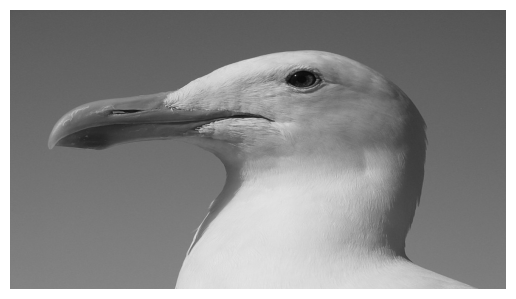

In [19]:
img_gray = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img_gray is None:
    raise FileNotFoundError(f"이미지를 읽을 수 없습니다: {IMAGE_PATH}")

img_gray = cv2.resize(
    img_gray,
    (TARGET_WIDTH, TARGET_HEIGHT),
    interpolation=cv2.INTER_AREA
)

input_np = img_gray.astype(np.float32) / 255.0

plt.imshow(input_np, cmap="gray")
plt.axis("off");

**잔상 효과 함수 (CPU):**

In [20]:
# TODO: NumPy를 사용하여 잔상 효과 함수 정의

# def motion_trail_np(image, weights):
#     """
#     NumPy를 이용해 이미지 잔상 효과를 생성한다.

#     출력 픽셀을 Python 반복문으로 하나씩 계산한다.
#     """

#     # TODO: 필요한 변수 정의 및 출력 배열 생성
#     output = ...

#     for output_y in _:
#         for output_x in _:

#             for shift in range(TRAIL_LENGTH):
#                 # TODO: x값 shift
#                 input_x = ...

#                 # TODO: shift한 픽셀을 누적
#                 # TODO: 출력 배열에 누적 픽셀 저장

#     return output

def motion_trail_np(image, weights):
    """
    NumPy를 이용해 이미지 잔상 효과를 생성한다.

    출력 픽셀을 Python 반복문으로 하나씩 계산한다.
    """

    image_height, image_width = image.shape
    trail_length = len(weights)

    output = np.zeros((image_height, image_width), dtype=np.float32)

    for output_y in range(image_height):
        for output_x in range(image_width):
            weighted_sum = 0.0

            for shift in range(trail_length):
                input_x = output_x - shift

                if input_x >= 0:
                    weighted_sum += image[output_y, input_x] * weights[shift]

            output[output_y, output_x] = weighted_sum

    return output

**잔상 효과 함수 (GPU):**

In [21]:
# TODO: CuPy를 사용하여 잔상 효과 함수 정의

# def motion_trail_cp(image, weights):
#     """
#     CuPy를 이용해 이미지 잔상 효과를 생성한다.

#     이동 거리는 Python에서 순차적으로 반복하지만,
#     각 이동 거리의 이미지 전체 계산은 GPU에서 병렬 처리한다.
#     """

#     # TODO: 필요한 변수 정의 및 출력 배열 생성
#     output = ...

#     for shift in range(TRAIL_LENGTH):
#         # TODO: 배열 slicing
#         input_region = image[_, _]
#         output_region = output[_, _]

#         # TODO: GPU가 병렬 연산할 output_region 계산 코드

#     return output

def motion_trail_cp(image, weights):
    """
    CuPy를 이용해 이미지 잔상 효과를 생성한다.

    이동 거리는 Python에서 순차적으로 반복하지만,
    각 이동 거리의 이미지 전체 계산은 GPU에서 병렬 처리한다.
    """

    image_height, image_width = image.shape
    trail_length = len(weights)

    output = cp.zeros((image_height, image_width), dtype=cp.float32)

    for shift in range(trail_length):
        input_region = image[:, :image_width - shift]
        output_region = output[:, shift:]

        output_region += input_region * weights[shift]

    return output

**가중치 설정:**

In [22]:
# 이동 거리가 멀어질수록 가중치를 작게 설정
weights_np = np.linspace(
    1.0,
    0.05,
    TRAIL_LENGTH,
    dtype=np.float32
)

# 전체 가중치의 합을 1로 정규화
weights_np /= np.sum(weights_np)

**NumPy CPU 처리:**

In [23]:
cpu_start = time.perf_counter()

output_np = motion_trail_np(
    image=input_np,
    weights=weights_np
)

cpu_end = time.perf_counter()

cpu_time = cpu_end - cpu_start

**CuPy 배열 준비:**

In [24]:
# TODO: NumPy 배열을 CuPy 배열로 변환

upload_start = time.perf_counter()

# input_cp = ...
# weights_cp = ...
input_cp = cp.asarray(input_np)
weights_cp = cp.asarray(weights_np)

cp.cuda.Stream.null.synchronize()

upload_end = time.perf_counter()

upload_time = upload_end - upload_start

**GPU 워밍업:**

In [25]:
warmup_image = cp.zeros((64, 64), dtype=cp.float32)
warmup_weights = cp.asarray(weights_np[:4])

_ = motion_trail_cp(
    image=warmup_image,
    weights=warmup_weights
)

cp.cuda.Stream.null.synchronize()

**CuPy GPU 처리:**

In [26]:
cp.cuda.Stream.null.synchronize()

gpu_start = time.perf_counter()

output_cp = motion_trail_cp(
    image=input_cp,
    weights=weights_cp
)

cp.cuda.Stream.null.synchronize()

gpu_end = time.perf_counter()

gpu_time = gpu_end - gpu_start

**GPU 결과를 CPU로 가져오기:**

In [27]:
# TODO: output_cp를 CPU 메모리로 복사

download_start = time.perf_counter()

# output_cp_np = ...
output_cp_np = cp.asnumpy(output_cp)

download_end = time.perf_counter()

download_time = download_end - download_start

**결과 비교:**

In [28]:
compute_speedup = cpu_time / gpu_time

gpu_total_time = upload_time + gpu_time + download_time
total_speedup = cpu_time / gpu_total_time

**결과 출력:**

In [29]:
print("========== NumPy CPU ==========")
print(f"Processing time: {cpu_time:.4f} seconds")
print()

print("========== CuPy GPU ==========")
print(f"CPU to GPU: {upload_time:.4f} seconds")
print(f"GPU processing: {gpu_time:.4f} seconds")
print(f"GPU to CPU: {download_time:.4f} seconds")
print(f"Total GPU time: {gpu_total_time:.4f} seconds")
print()

print("========== Comparison ==========")
print(f"Compute-only speedup: {compute_speedup:.2f}x")
print(f"Including transfers: {total_speedup:.2f}x")

========== NumPy CPU ==========
Processing time: 11.1143 seconds

========== CuPy GPU ==========
CPU to GPU: 0.8459 seconds
GPU processing: 0.0246 seconds
GPU to CPU: 0.0023 seconds
Total GPU time: 0.8729 seconds

========== Comparison ==========
Compute-only speedup: 451.29x
Including transfers: 12.73x


**이미지 출력:**

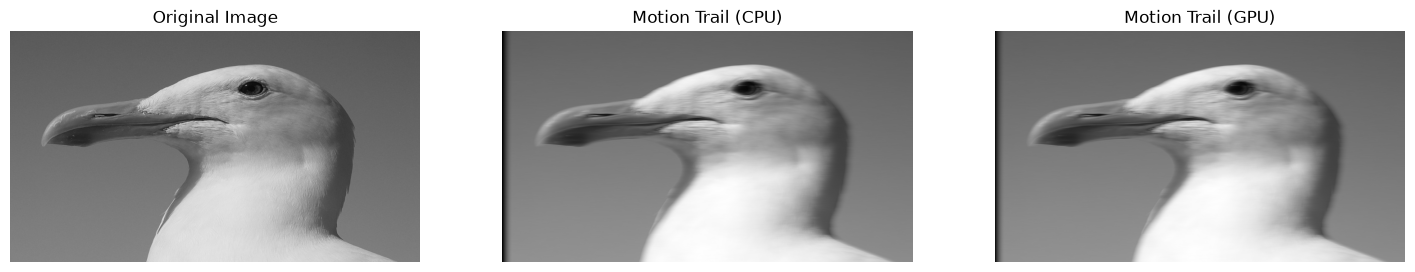

In [30]:
plt.figure(figsize=(18,12))

plt.subplot(1,3,1), plt.imshow(input_np, cmap="gray"), plt.title("Original Image")
plt.subplot(1,3,2), plt.imshow(output_np, cmap="gray"), plt.title("Motion Trail (CPU)")
plt.subplot(1,3,3), plt.imshow(output_cp_np, cmap="gray"), plt.title("Motion Trail (GPU)")

for ax in plt.gcf().axes:
    ax.axis("off")

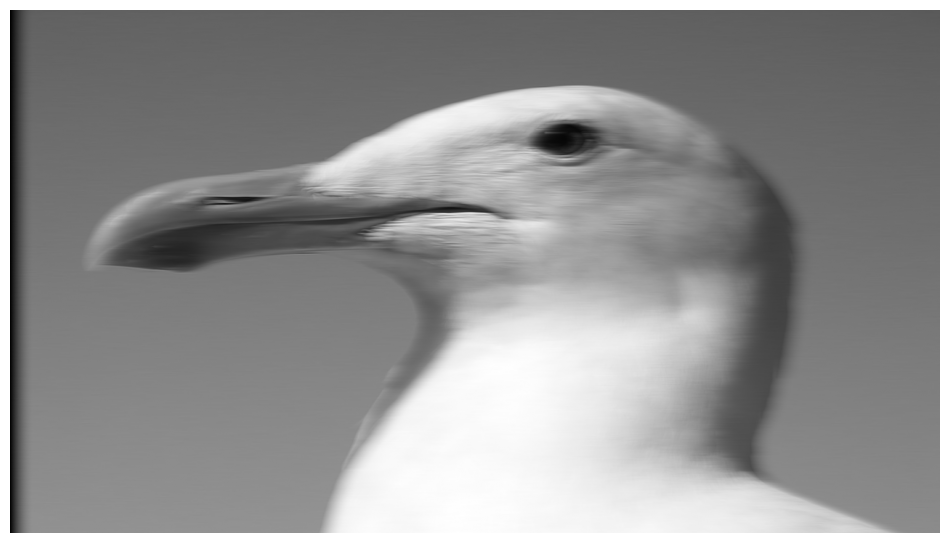

In [31]:
plt.figure(figsize=(12,8))
plt.imshow(output_cp_np, cmap="gray")
plt.axis("off");

## $5)$ CuPy를 활용한 배열 연산 GPU 가속 2 – Convolution 연산

이전 실습에서는 이미지 배열을 여러 픽셀만큼 이동하고, 각 배열에 서로 다른 가중치를 곱한 뒤 출력 배열에 누적하여 이미지 잔상 효과를 구현했습니다.

이 과정에서 이동 거리를 제어하는 for문은 Python에서 순차적으로 실행되지만, 각 반복에서 수행되는 이미지 배열 전체의 곱셈과 덧셈은 GPU에서 병렬로 처리된다는 점을 확인했습니다.

이번 실습에서는 이러한 배열 이동과 가중치 누적 방식을 2차원으로 확장하여 convolution 연산을 구현합니다.

이전에 정의한 `convolution2d()` 함수는 NumPy를 사용하여 출력 이미지의 픽셀을 하나씩 순차적으로 계산합니다.

각 출력 위치에서 커널 크기만큼 이미지 영역을 잘라낸 뒤, 이미지 영역과 커널을 원소별로 곱하고 그 결과를 모두 더하여 하나의 출력 픽셀을 생성합니다.

```text
출력 위치 하나 선택
→ 커널 크기의 이미지 영역 추출
→ 이미지 영역과 커널의 가중합 계산
→ 출력 픽셀 하나 저장
```

이 방식은 convolution의 원리를 직접 확인하기에는 적합하지만, 이미지의 높이와 너비만큼 Python 반복문을 실행해야 하므로 큰 이미지에서는 처리 시간이 오래 걸립니다.

<br>

이번에는 이전에 정의한 `convolution2d()` 함수와 동일한 결과를 계산하는 CuPy 기반의 `convolution2d_cp()` 함수를 작성합니다.

CuPy 버전에서는 출력 픽셀을 하나씩 반복하지 않고, 커널의 각 원소를 순차적으로 선택합니다. 그리고 모든 출력 위치에서 현재 커널 원소와 대응되는 입력 픽셀을 배열로 선택한 뒤, 해당 커널 가중치를 곱하여 출력 배열 전체에 누적합니다.

```text
커널 원소 하나 선택
→ 모든 출력 위치에서 대응되는 입력 픽셀 선택
→ 배열 전체에 현재 커널 가중치 적용
→ 출력 배열 전체에 누적
```

두 함수는 계산 순서가 다르지만, 최종적으로 각 출력 픽셀에는 이미지 영역과 커널의 동일한 가중합이 저장됩니다.

<br>

**함수의 입력으로는 이전 실습과 동일한 이미지를 사용합니다:**

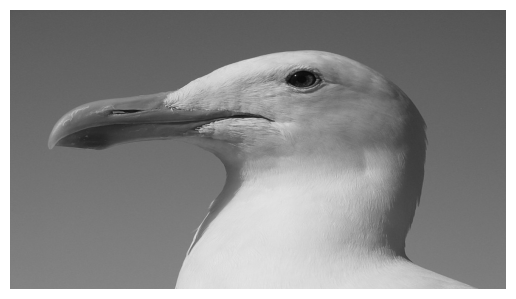

In [32]:
plt.imshow(input_np, cmap="gray")
plt.axis("off");

**Convolution 함수 정의 (CuPy):**

In [33]:
# TODO: CuPy를 사용하여 2차원 convolution 함수 정의

# def convolution2d_cp(image, kernel, bias=0.0, stride=1, padding=0):
#     """
#     CuPy를 이용한 2차원 convolution.

#     커널의 위치는 Python 반복문으로 순차 처리하고,
#     각 위치에 해당하는 출력 배열 전체 연산은 GPU에서 처리한다.
#     """

#     pass

def convolution2d_cp(image, kernel, bias=0.0, stride=1, padding=0):
    """
    CuPy를 이용한 2차원 convolution.

    커널의 위치는 Python 반복문으로 순차 처리하고,
    각 위치에 해당하는 출력 배열 전체 연산은 GPU에서 처리한다.
    """

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # GPU 배열에 padding 적용
    padded_image = cp.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode="constant",
        constant_values=0
    )

    # 출력 배열 크기 계산
    output_height = (padded_image.shape[0] - kernel_height) // stride + 1
    output_width = (padded_image.shape[1] - kernel_width) // stride + 1

    # 출력 배열 생성
    output = cp.zeros((output_height, output_width), dtype=cp.float32)

    # 커널의 각 원소를 순차적으로 선택
    for kernel_y in range(kernel_height):
        for kernel_x in range(kernel_width):

            # 모든 출력 위치에서 현재 커널 원소와 대응되는 입력 픽셀들을 선택
            image_region = padded_image[
                kernel_y:kernel_y + output_height * stride:stride,
                kernel_x:kernel_x + output_width * stride:stride
            ]

            # 현재 커널 원소가 모든 출력 픽셀에 미치는 값 누적
            output += image_region * kernel[kernel_y, kernel_x]

    # 모든 출력 픽셀에 동일한 bias 추가
    output += bias

    return output

**NumPy CPU 처리:**

In [35]:
def convolution2d(image, kernel, bias=0.0, stride=1, padding=0):
    """
    2차원 이미지에 하나의 CNN 필터를 적용.

    Parameters
    ----------
    image   : np.ndarray    :   입력 이미지, shape = (height, width)
    kernel  : np.ndarray    :   CNN 필터, shape = (kernel_height, kernel_width)
    bias    : float         :   필터 출력에 더할 편향
    stride  : int           :   필터가 이동하는 간격
    padding : int           :   입력 이미지 가장자리에 추가할 픽셀의 개수

    Returns
    -------
    output  : np.ndarray    : 편향까지 적용된 convolution 결과
    """

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # 이미지 가장자리에 zero padding 적용
    padded_image = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode="constant",
        constant_values=0
    )

    # (H, W: 입력 이미지 높이 및 너비, P: Padding 픽셀 값, S: Stride 픽셀 값)
    # Convolution 출력 이미지 높이 = floor((H + 2P - K) / S) + 1
    output_height = (padded_image.shape[0] - kernel_height) // stride + 1

    # Convolution 출력 이미지 너비 = floor((W + 2P - K) / S) + 1
    output_width = (padded_image.shape[1] - kernel_width) // stride + 1

    # 계산한 크기로 출력 이미지 준비
    output = np.zeros((output_height, output_width), dtype=np.float32)

    # 커널을 움직이며 필터 적용
    for output_y in range(output_height):
        for output_x in range(output_width):
            # 커널을 적용할 이미지 영역의 좌측상단
            start_y = output_y * stride
            start_x = output_x * stride

            # 커널을 적용할 이미지 영역을 crop
            image_region = padded_image[
                start_y:start_y + kernel_height,
                start_x:start_x + kernel_width
            ]

            # 필터를 적용하여 가중합 계산
            weighted_sum = np.sum(image_region * kernel)

            # 편향 적용
            output[output_y, output_x] = weighted_sum + bias

    return output

In [37]:
# x축 방향 edge (세로 선) 검출 필터
dx_edge_filter = np.array(
    [
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ],
    dtype=np.float32
)

# y축 방향 edge (가로 선) 검출 필터
dy_edge_filter = np.array(
    [
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1]
    ],
    dtype=np.float32
)

In [38]:
# 너무 약한 특징 (0.2 이하)은 무시
dx_bias = -0.2
dy_bias = -0.2

In [39]:
def relu(x):
    return np.maximum(0, x)

In [40]:
# TODO: 기존에 정의한 convolution2d 함수를 사용하여 convolution을 CPU로 처리
# TODO: 변수 재사용 가능

# output_dx_np = ...
# output_dy_np = ...
# cpu_time = ...
# relu_dx_np = ...
# relu_dy_np = ...

cpu_start = time.perf_counter()

output_dx_np = convolution2d(
    image=input_np,
    kernel=dx_edge_filter,
    bias=dx_bias,
    stride=1,
    padding=1
)

output_dy_np = convolution2d(
    image=input_np,
    kernel=dy_edge_filter,
    bias=dy_bias,
    stride=1,
    padding=1
)

cpu_end = time.perf_counter()
cpu_time = cpu_end - cpu_start

relu_dx_np = relu(output_dx_np)
relu_dy_np = relu(output_dy_np)

**CuPy GPU 처리:**

In [41]:
# TODO: convolution을 GPU로 처리 (변환-워밍업-처리 파이프라인 구현)
# TODO: 변수 재사용 가능

# output_dx_cp = ...
# output_dy_cp = ...
# gpu_time = ...
# relu_dx_cp_np = ...
# relu_dy_cp_np = ...

# NumPy 배열을 CuPy GPU 배열로 변환
input_cp = cp.asarray(input_np)
dx_edge_filter_cp = cp.asarray(dx_edge_filter)
dy_edge_filter_cp = cp.asarray(dy_edge_filter)

# GPU 워밍업
warmup_image = cp.zeros((64, 64), dtype=cp.float32)
warmup_kernel = cp.ones((3, 3), dtype=cp.float32)

_ = convolution2d_cp(
    image=warmup_image,
    kernel=warmup_kernel,
    padding=1
)

cp.cuda.Stream.null.synchronize()

# CuPy GPU 처리
cp.cuda.Stream.null.synchronize()
gpu_start = time.perf_counter()

output_dx_cp = convolution2d_cp(
    image=input_cp,
    kernel=dx_edge_filter_cp,
    bias=dx_bias,
    stride=1,
    padding=1
)

output_dy_cp = convolution2d_cp(
    image=input_cp,
    kernel=dy_edge_filter_cp,
    bias=dy_bias,
    stride=1,
    padding=1
)

cp.cuda.Stream.null.synchronize()
gpu_end = time.perf_counter()

gpu_time = gpu_end - gpu_start

# GPU 결과를 CPU의 NumPy 배열로 변환
output_dx_cp_np = cp.asnumpy(output_dx_cp)
output_dy_cp_np = cp.asnumpy(output_dy_cp)

# ReLU 적용
relu_dx_cp_np = relu(output_dx_cp_np)
relu_dy_cp_np = relu(output_dy_cp_np)

**결과 출력:**

In [42]:
# TODO: CPU/GPU 결과 비교 및 출력

print(f"NumPy CPU time: {cpu_time:.6f} seconds")
print(f"CuPy GPU time: {gpu_time:.6f} seconds")
print(f"Speedup: {cpu_time / gpu_time:.2f}x")

NumPy CPU time: 11.016712 seconds
CuPy GPU time: 0.038932 seconds
Speedup: 282.97x


**이미지 출력:**

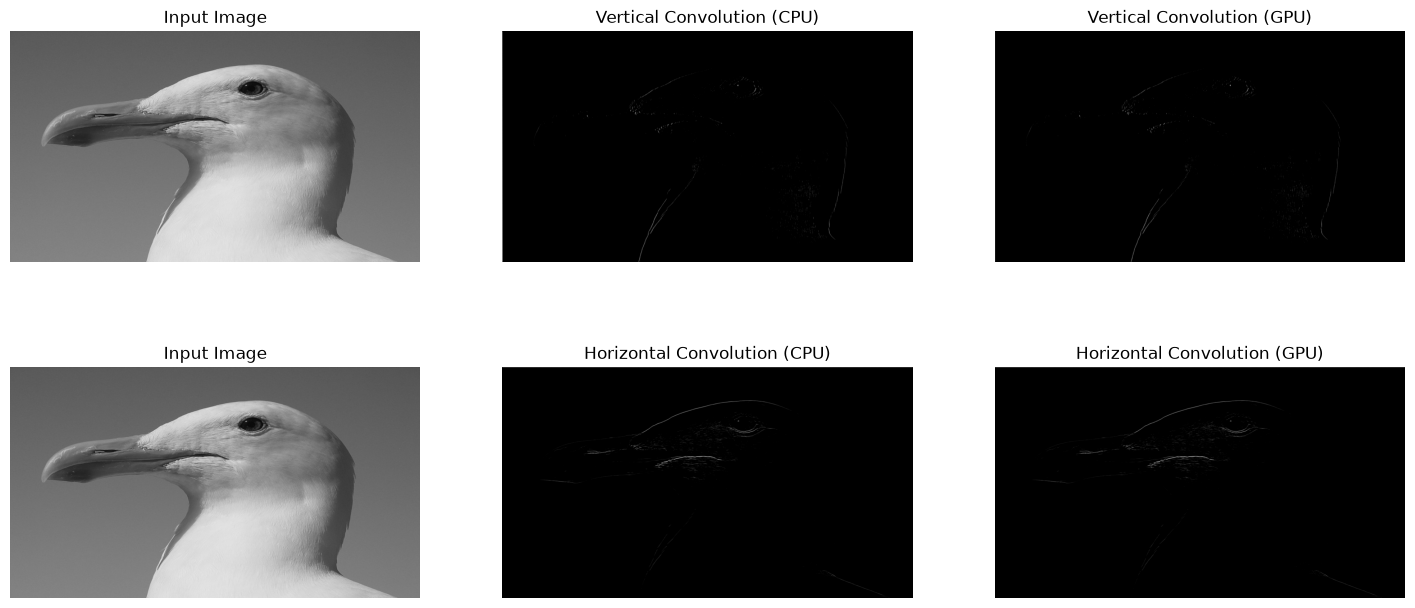

In [43]:
plt.figure(figsize=(18,8))

plt.subplot(2,3,1), plt.imshow(input_np, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,2), plt.imshow(relu_dx_np, cmap="gray"), plt.title("Vertical Convolution (CPU)")
plt.subplot(2,3,3), plt.imshow(relu_dx_cp_np, cmap="gray"), plt.title("Vertical Convolution (GPU)")
plt.subplot(2,3,4), plt.imshow(input_np, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,5), plt.imshow(relu_dy_np, cmap="gray"), plt.title("Horizontal Convolution (CPU)")
plt.subplot(2,3,6), plt.imshow(relu_dy_cp_np, cmap="gray"), plt.title("Horizontal Convolution (GPU)")

for ax in plt.gcf().axes:
    ax.axis("off")

---

# H. GPU 병렬 연산 (PyTorch)

#### $1)$ PyTorch 개요

GPU를 활용하면 배열 연산뿐만 아니라 딥러닝 모델의 학습과 추론도 빠르게 수행할 수 있습니다.

이를 위해 GPU 연산, 자동 미분, 신경망 모델 구성을 지원하는 딥러닝 프레임워크인 `PyTorch`를 사용합니다.

<br>

`PyTorch`:
* GPU 연산을 지원하는 오픈소스 딥러닝 프레임워크
* NumPy 배열과 유사한 다차원 배열인 Tensor 사용
* NVIDIA CUDA를 활용하여 딥러닝 연산을 GPU에서 가속
* 자동 미분을 통해 신경망의 가중치와 편향을 학습
* CNN, RNN, Transformer 등 다양한 딥러닝 모델 구현 가능

<br>

`PyTorch` 활용 사례:
* 이미지 분류
* 객체 검출
* 이미지 Segmentation
* 자세 추정
* 자연어 처리
* 음성 인식
* 생성형 AI
* 강화학습
* 로봇 인지
* Edge AI 추론

<br>

`PyTorch` 주요 기능:
* Tensor 연산
* 자동 미분
* 신경망 Layer, 손실 함수, Optimizer 제공
* 데이터 로딩 및 전처리
* 모델 구성 및 학습
* 모델 저장 및 불러오기

#### $2)$ PyTorch 기본 문법

**`PyTorch` 주요 구성 요소:**

* 다차원 배열
    ```text
        torch.Tensor
    ```

* 자동 미분과 Gradient 계산
    ```text
        torch.autograd
        torch.no_grad
        torch.enable_grad
    ```

* 신경망 Layer와 Loss Function
    ```text
        torch.nn
        torch.nn.functional
    ```

* SGD, Adam 등의 Optimizer
    ```text
        torch.optim
    ```

* Dataset과 DataLoader
    ```text
        torch.utils.data
    ```

* PyTorch의 컴퓨터 비전 라이브러리 (이미지 Dataset, Transform, 모델)
    ```text
        torchvision
    ```

**a) 기본적인 Import:**

In [44]:
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

**b) CPU Tensor 생성:**

In [46]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.13.0+cpu
Torchvision version: 0.28.0+cpu


In [47]:
x_cpu = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]])

print(x_cpu)
print(x_cpu.device)

tensor([[1., 2.],
        [3., 4.]])
cpu


**c) GPU Tensor 생성:**

In [48]:
if torch.cuda.is_available():
    x_gpu = x_cpu.to("cuda")

    print(x_gpu)
    print(x_gpu.device)

**d) Device 설정:**

In [49]:
device = torch.device("cpu")

print("Selected device:", device)

Selected device: cpu


In [50]:
device = torch.device("cuda")

print("Selected device:", device)

Selected device: cuda


In [51]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("CUDA Availability:", torch.cuda.is_available())
print("Selected device:", device)

CUDA Availability: False
Selected device: cpu


**e) 모델 생성 및 장치 할당:**

앞선 실습에서 정의한 `SimpleCNN` 클래스를 다시 보도록 합시다.

In [52]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        self.fc1 = nn.Linear(
            16 * 7 * 7,
            64,
        )

        self.fc2 = nn.Linear(
            64,
            10,
        )

    def forward(self, x, return_features=False):
        conv1_output = self.conv1(x)
        relu1_output = F.relu(conv1_output)
        pool1_output = self.pool(relu1_output)
        conv2_output = self.conv2(pool1_output)
        relu2_output = F.relu(conv2_output)
        pool2_output = self.pool(relu2_output)
        flattened = torch.flatten(pool2_output, start_dim=1)
        fc1_output = F.relu(self.fc1(flattened))
        logits = self.fc2(fc1_output)

        if return_features:
            features = {
                "conv1": conv1_output,
                "relu1": relu1_output,
                "pool1": pool1_output,
                "conv2": conv2_output,
                "relu2": relu2_output,
                "pool2": pool2_output,
            }

            return logits, features

        return logits

In [53]:
# 모델 생성
model = SimpleCNN()

# 모델을 장치에 할당
model = model.to(device)

print("Device:", device)
print(model)

Device: cpu
SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


**f) 데이터셋 불러오기:**

데이터셋의 원본은 이미지입니다. 이미지는 기본적으로 ‘높이 × 너비 × 채널’ 구조로 존재합니다. 하지만 PyTorch 모델은 계산 효율을 위해 ‘채널 × 높이 × 너비’ 형태로 입력을 받습니다.

또한, 원본 이미지는 0 ~ 255 사이의 정수값을 가지는 반면, PyTorch 모델은 학습의 안정성을 위해 0.0 ~ 1.0 사이의 실수값을 요구합니다.

이때 `transforms.ToTensor()`라는 변환기를 사용하면, 이미지 형식을 PyTorch 모델에 맞춘 최적의 형식으로 자동 변환할 수 있습니다.

<br>

구체적으로는 다음 두 가지 중요한 일을 자동으로 처리합니다.
* 형태 변환: 일반 이미지 파일 형식(H, W, C)을 PyTorch 연산 표준인 (C, H, W) 구조로 순서를 변경
* 스케일링: 0~255 사이의 정수로 표현된 픽셀 값을 0.0~1.0 사이의 실수(Float32) 값으로 자동 변환(정규화)

해당 과정은 딥러닝 모델의 안정적인 학습을 위해 필수입니다.

In [54]:
# 이미지 데이터를 PyTorch 모델이 학습할 수 있는 텐서(Tensor) 형태로 변환하는 변환기 생성
transform = transforms.ToTensor()

In [55]:
# 학습 데이터 불러오기
train_dataset = datasets.MNIST(
    root="src/datasets",  # 데이터셋을 저장 및 불러오기 위한 디렉토리
    train=True,           # 학습용 데이터만 불러오는 설정
    transform=transform,  # 텐서 변환기를 데이터셋에 적용
    download=True,        # 지정한 경로에 데이터가 없으면 자동으로 다운로드
)

# 테스트 데이터 불러오기
test_dataset = datasets.MNIST(
    root="src/datasets",  # 데이터셋 디렉토리
    train=False,          # 학습용/테스트용 데이터 로드 설정
    transform=transform,  # 텐서 변환기
    download=True,        # 최초 다운로드
)

**g) DataLoader 생성:**

DataLoader의 역할:
* Dataset은 이미지 한 장과 Label 하나를 반환 (`image, label = train_dataset[0]`)
* DataLoader는 총 70,000개의 데이터를 지정한 사이즈의 하나의 묶음(Batch)으로 불러와 모델에 전달
* 실제 학습에서는 한 장씩 모델에 입력 값으로 전달하기 보다는, 여러 이미지를 하나의 Batch로 묶어서 입력에 전달한다

DataLoader이 제공하는 기능:
* Batch 생성
* Batch 단위 반복
* 데이터 순서 섞기
* 데이터 로딩 과정 관리

In [56]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=0,
)

**h) 데이터셋의 단일 image/label 확인:**

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([1, 28, 28])
Label: 5
Minimum: 0.0
Maximum: 1.0


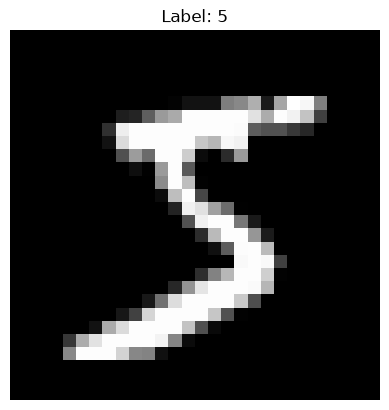

In [57]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)
print("Minimum:", image.min().item())
print("Maximum:", image.max().item())

image_2d = image.squeeze(0)

plt.imshow(image_2d, cmap="gray"), plt.title(f"Label: {label}")
plt.axis("off");

**i) 데이터셋을 GPU에 할당:**

DataLoader를 '반복자(Iterator)'로 변환한 뒤, 첫 번째 Batch만 불러오기:

In [58]:
images, labels = next(iter(train_loader))

print(type(images))
print(type(labels))
print()
print("이미지 Batch 형태:", images.shape)
print()
print("레이블 Batch 텐서 :\n", labels)

<class 'torch.Tensor'>
<class 'torch.Tensor'>

이미지 Batch 형태: torch.Size([64, 1, 28, 28])

레이블 Batch 텐서 :
 tensor([8, 1, 3, 1, 6, 9, 7, 4, 1, 8, 5, 0, 1, 7, 8, 4, 7, 0, 7, 9, 2, 4, 9, 5,
        7, 6, 3, 7, 3, 2, 5, 8, 5, 7, 1, 2, 8, 8, 6, 0, 1, 2, 1, 1, 0, 8, 1, 1,
        8, 3, 7, 0, 8, 6, 4, 9, 1, 0, 5, 9, 3, 7, 6, 7])


이미지와 레이블 Batch 텐서를 장치(GPU)에 할당:

In [59]:
print("images 텐서의 과거 위치:", images.device)
print("labels 텐서의 과거 위치:", labels.device)

images = images.to(device)
labels = labels.to(device)

print("images 텐서의 현재 위치:", images.device)
print("labels 텐서의 현재 위치:", labels.device)

images 텐서의 과거 위치: cpu
labels 텐서의 과거 위치: cpu
images 텐서의 현재 위치: cpu
labels 텐서의 현재 위치: cpu


***※ 주의: 모델과 Tensor는 같은 Device에 있어야 한다***

In [60]:
model = SimpleCNN()
model = model.to(device)

print("모델 위치:", device)

모델 위치: cpu


In [61]:
images, labels = next(iter(train_loader))

print("입력 이미지 텐서 위치:", images.device)

입력 이미지 텐서 위치: cpu


In [62]:
try:
    outputs = model(images)
except RuntimeError as e:
    print(f"예러: {e}")

---

<br><br><div style="text-align: right; color: gray; font-style: italic;">
© 2026, 김규래 (Kyu Rae Kim), All rights reserved.&emsp;<br><br>
This material is provided solely for the intended instructional purpose.&emsp;<br>
Redistribution, reproduction, modification, adaptation, or reuse of this material in any form without prior written permission from the copyright holder is prohibited.&emsp;
</div>